# Time Series Analysis and Forecasting

This notebook performs time series forecasting for each cluster using multiple models:
- Prophet
- XGBoost
- SARIMAX
- Holt-Winters

We evaluate each model using multiple metrics and select the best model for each cluster.


## Section 1: Imports and Configuration


In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import xgboost as xgb

from prophet import Prophet

## Section 2: Load and Prepare Data


In [7]:
data_path = '../data/processed/2025-12-21_clusters_results_dataset.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())
print(f"\nDate range: {df['report_created_at'].min()} to {df['report_created_at'].max()}")

df['report_created_at'] = pd.to_datetime(df['report_created_at'])

df.head()

Dataset shape: (5408, 12)

Columns: ['user_id', 'report_id', 'report_created_at', 'cluster', 'cluster_number', 'report_state', 'report_city', 'report_country', 'bad_time', 'report_latitude', 'report_longitude', 'report_symptoms']

Cluster distribution:
cluster
0       8
1    5399
2       1
Name: count, dtype: int64

Date range: 2023-08-07 to 2024-12-31


,user_id,report_id,report_created_at,cluster,cluster_number,report_state,report_city,report_country,bad_time,report_latitude,report_longitude,report_symptoms
0,10021,6522535,2024-10-17,1,1,NaN,NaN,NaN,1,-15.869060,-47.967371,['paladareolfato\n- CongestãoNasal\n- Coriza\n...
1,10073,5769908,2023-09-05,1,1,Federal District,Taguatinga,Brazil,0,-15.856337,-48.039371,['Mal-estar\n- Diarreia']
2,10073,5847406,2023-09-27,1,1,Federal District,Taguatinga,Brazil,0,-15.856337,-48.039399,['Cansaco']
3,10073,5942219,2023-10-26,1,1,Federal District,Brasília,Brazil,0,-15.796527,-47.866100,['Cansaco']
4,10073,6192210,2024-04-05,1,1,Federal District,Águas Claras,Brazil,0,-15.857348,-48.037113,['Cansaco\n- DificuldadeParaRespirar\n- Fadiga']


## Section 3: Aggregate Data by Date and Cluster


In [8]:
ts_data = df.groupby(['report_created_at', 'cluster']).size().reset_index(name='count')
ts_data = ts_data.sort_values(['cluster', 'report_created_at']).reset_index(drop=True)

all_dates = pd.date_range(start=ts_data['report_created_at'].min(), 
                          end=ts_data['report_created_at'].max(), 
                          freq='D')
all_clusters = sorted(df['cluster'].unique())

complete_ts = []
for cluster in all_clusters:
    cluster_dates = pd.DataFrame({
        'report_created_at': all_dates,
        'cluster': cluster
    })
    cluster_data = ts_data[ts_data['cluster'] == cluster]
    cluster_dates = cluster_dates.merge(
        cluster_data[['report_created_at', 'count']], 
        on='report_created_at', 
        how='left'
    )
    cluster_dates['count'] = cluster_dates['count'].fillna(0).astype(int)
    complete_ts.append(cluster_dates)

ts_complete = pd.concat(complete_ts, ignore_index=True)

print(f"Complete time series shape: {ts_complete.shape}")
print(f"\nDate range: {ts_complete['report_created_at'].min()} to {ts_complete['report_created_at'].max()}")
print(f"\nSample data:")
ts_complete.head(10)


Complete time series shape: (1539, 3)

Date range: 2023-08-07 00:00:00 to 2024-12-31 00:00:00

Sample data:


,report_created_at,cluster,count
0,2023-08-07,0,0
1,2023-08-08,0,0
2,2023-08-09,0,0
3,2023-08-10,0,0
4,2023-08-11,0,0
5,2023-08-12,0,1
6,2023-08-13,0,0
7,2023-08-14,0,0
8,2023-08-15,0,0
9,2023-08-16,0,0


## Section 4: Evaluation Metrics and Statistical Tests


In [ ]:
def calculate_metrics(y_true, y_pred, y_train=None):
    metrics = {}
    
    metrics['mse'] = mean_squared_error(y_true, y_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    metrics['mae'] = mean_absolute_error(y_true, y_pred)
    
    mask = y_true != 0
    if mask.sum() > 0:
        metrics['mape'] = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        metrics['mape'] = np.nan
    
    if y_train is not None and len(y_train) > 1:
        naive_forecast = np.mean(np.abs(np.diff(y_train)))
        if naive_forecast > 0:
            metrics['mase'] = metrics['mae'] / naive_forecast
        else:
            metrics['mase'] = np.nan
    else:
        metrics['mase'] = np.nan
    
    metrics['mean_forecast_error'] = np.mean(y_pred - y_true)
    
    if len(y_true) > 1:
        actual_direction = np.diff(y_true) > 0
        pred_direction = np.diff(y_pred) > 0
        metrics['directional_accuracy'] = np.mean(actual_direction == pred_direction) * 100
    else:
        metrics['directional_accuracy'] = np.nan
    
    return metrics

def calculate_prediction_interval_coverage(y_true, y_lower, y_upper):
    if y_lower is None or y_upper is None:
        return np.nan
    
    coverage = np.mean((y_true >= y_lower) & (y_true <= y_upper)) * 100
    return coverage

def jarque_bera_test(residuals):
    if len(residuals) < 2:
        return {'statistic': np.nan, 'pvalue': np.nan}
    
    try:
        statistic, pvalue = stats.jarque_bera(residuals)
        return {'statistic': statistic, 'pvalue': pvalue}
    except:
        return {'statistic': np.nan, 'pvalue': np.nan}

def adf_test(series):
    if len(series) < 2:
        return {'statistic': np.nan, 'pvalue': np.nan}
    
    try:
        result = adfuller(series.dropna())
        return {'statistic': result[0], 'pvalue': result[1]}
    except:
        return {'statistic': np.nan, 'pvalue': np.nan}

In [ ]:
def fit_prophet_model(train_data, test_periods):
    prophet_df = pd.DataFrame({
        'ds': train_data['ds'],
        'y': train_data['y']
    })
    
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        interval_width=0.95
    )
    model.fit(prophet_df)
    
    future = model.make_future_dataframe(periods=test_periods)
    forecast = model.predict(future)
    
    return forecast, model

### 5.2 XGBoost Model

In [12]:
def create_xgboost_features(series, dates, max_lag=14):
    df = pd.DataFrame({
        'value': series,
        'date': dates
    })
    
    for lag in [1, 2, 3, 7, 14]:
        if lag <= max_lag:
            df[f'lag_{lag}'] = df['value'].shift(lag)
    
    df['ma_7'] = df['value'].rolling(window=7, min_periods=1).mean()
    df['ma_14'] = df['value'].rolling(window=14, min_periods=1).mean()
    
    df['day_of_week'] = pd.to_datetime(df['date']).dt.dayofweek
    df['month'] = pd.to_datetime(df['date']).dt.month
    df['day_of_month'] = pd.to_datetime(df['date']).dt.day
    df['quarter'] = pd.to_datetime(df['date']).dt.quarter
    df['year'] = pd.to_datetime(df['date']).dt.year
    
    df['trend'] = range(len(df))
    
    return df

def fit_xgboost_model(train_data, train_dates, test_periods, max_lag=14):
    train_features = create_xgboost_features(train_data, train_dates, max_lag)
    train_features = train_features.dropna()
    
    if len(train_features) == 0:
        last_value = train_data[-1]
        forecast = np.full(test_periods, last_value)
        lower_bound = forecast - np.std(train_data) * 1.96
        upper_bound = forecast + np.std(train_data) * 1.96
        return forecast, lower_bound, upper_bound, None
    
    feature_cols = [col for col in train_features.columns if col not in ['value', 'date']]
    X_train = train_features[feature_cols].values
    y_train = train_features['value'].values
    
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    )
    model.fit(X_train, y_train)
    
    forecasts = []
    last_values = train_data[-max_lag:].tolist()
    last_date = train_dates[-1]
    
    for i in range(test_periods):
        next_date = last_date + pd.Timedelta(days=1)
        
        feature_dict = {}
        for lag in [1, 2, 3, 7, 14]:
            if lag <= max_lag and lag <= len(last_values):
                feature_dict[f'lag_{lag}'] = last_values[-lag]
            else:
                feature_dict[f'lag_{lag}'] = np.nan
        
        feature_dict['ma_7'] = np.mean(last_values[-7:]) if len(last_values) >= 7 else np.mean(last_values)
        feature_dict['ma_14'] = np.mean(last_values[-14:]) if len(last_values) >= 14 else np.mean(last_values)
        
        feature_dict['day_of_week'] = next_date.dayofweek
        feature_dict['month'] = next_date.month
        feature_dict['day_of_month'] = next_date.day
        feature_dict['quarter'] = next_date.quarter
        feature_dict['year'] = next_date.year
        feature_dict['trend'] = len(train_data) + i
        
        X_pred = pd.DataFrame([feature_dict])[feature_cols].values
        pred = model.predict(X_pred)[0]
        forecasts.append(pred)
        
        last_values.append(pred)
        if len(last_values) > max_lag:
            last_values.pop(0)
        last_date = next_date
    
    forecasts = np.array(forecasts)
    
    train_pred = model.predict(X_train)
    train_residuals = y_train - train_pred
    std_residual = np.std(train_residuals)
    
    lower_bound = forecasts - 1.96 * std_residual
    upper_bound = forecasts + 1.96 * std_residual
    
    return forecasts, lower_bound, upper_bound, model

### 5.3 SARIMAX Model

In [13]:
def fit_sarimax_model(train_data, test_periods, order=(1,1,1), seasonal_order=(1,1,1,7)):
    try:
        model = SARIMAX(train_data, order=order, seasonal_order=seasonal_order)
        fitted_model = model.fit(disp=False, maxiter=200)
        
        forecast_result = fitted_model.get_forecast(steps=test_periods)
        forecast = forecast_result.predicted_mean
        conf_int = forecast_result.conf_int()
        
        lower_bound = conf_int.iloc[:, 0].values
        upper_bound = conf_int.iloc[:, 1].values
        
        return forecast.values, lower_bound, upper_bound, fitted_model
    except Exception as e:
        print(f"SARIMAX fitting error: {e}")
        last_value = train_data.iloc[-1] if hasattr(train_data, 'iloc') else train_data[-1]
        forecast = np.full(test_periods, last_value)
        lower_bound = forecast - np.std(train_data) * 1.96
        upper_bound = forecast + np.std(train_data) * 1.96
        return forecast, lower_bound, upper_bound, None

### 5.4 Holt-Winters Model

In [ ]:
def fit_holtwinters_model(train_data, test_periods, seasonal_periods=7):
    try:
        if len(train_data) >= seasonal_periods * 2:
            model = ExponentialSmoothing(
                train_data, 
                seasonal_periods=seasonal_periods,
                trend='add',
                seasonal='add'
            )
        else:
            model = ExponentialSmoothing(
                train_data,
                trend='add',
                seasonal=None
            )
        
        fitted_model = model.fit(optimized=True)
        
        forecast_result = fitted_model.forecast(steps=test_periods)
        forecast = forecast_result.values if hasattr(forecast_result, 'values') else forecast_result
        
        residuals = train_data - fitted_model.fittedvalues
        std_residual = np.std(residuals)
        
        lower_bound = forecast - 1.96 * std_residual
        upper_bound = forecast + 1.96 * std_residual
        
        return forecast, lower_bound, upper_bound, fitted_model
    except Exception as e:
        print(f"Holt-Winters fitting error: {e}")
        last_value = train_data.iloc[-1] if hasattr(train_data, 'iloc') else train_data[-1]
        forecast = np.full(test_periods, last_value)
        lower_bound = forecast - np.std(train_data) * 1.96
        upper_bound = forecast + np.std(train_data) * 1.96
        return forecast, lower_bound, upper_bound, None

## Section 6: Configuration and Initialization


In [ ]:
TEST_SIZE = 0.2
MIN_TRAIN_SIZE = 30

current_date = datetime.now().strftime('%Y%m%d')

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../data/results', exist_ok=True)

all_results = []
all_forecasts = {}

clusters = sorted(ts_complete['cluster'].unique())

print(f"Processing {len(clusters)} clusters...")
print(f"Models to evaluate: Prophet, XGBoost, SARIMAX, Holt-Winters")
print(f"Test size: {TEST_SIZE*100}%")
print("\n" + "="*80)

Processing 3 clusters...
Models to evaluate: Prophet, XGBoost, SARIMAX, Holt-Winters
Test size: 20.0%



## Section 7: Train Models and Generate Forecasts

In [ ]:
for cluster in clusters:
    print(f"\n{'='*80}")
    print(f"Processing Cluster {cluster}")
    print(f"{'='*80}")
    
    cluster_data = ts_complete[ts_complete['cluster'] == cluster].copy()
    cluster_data = cluster_data.sort_values('report_created_at').reset_index(drop=True)
    
    ts_values = cluster_data['count'].values
    ts_dates = cluster_data['report_created_at'].values
    
    print(f"Total observations: {len(ts_values)}")
    print(f"Date range: {ts_dates[0]} to {ts_dates[-1]}")
    print(f"Mean count: {ts_values.mean():.2f}, Std: {ts_values.std():.2f}")
    
    if len(ts_values) < MIN_TRAIN_SIZE:
        print(f"WARNING: Cluster {cluster} has only {len(ts_values)} observations. Skipping...")
        continue
    
    split_idx = int(len(ts_values) * (1 - TEST_SIZE))
    train_data = ts_values[:split_idx]
    test_data = ts_values[split_idx:]
    train_dates = ts_dates[:split_idx]
    test_dates = ts_dates[split_idx:]
    
    print(f"Train size: {len(train_data)}, Test size: {len(test_data)}")
    
    cluster_forecasts = {}
    
    print(f"\n--- Fitting Prophet Model ---")
    try:
        prophet_train = pd.DataFrame({
            'ds': train_dates,
            'y': train_data
        })
        
        forecast_df, prophet_model = fit_prophet_model(prophet_train, len(test_data))
        
        prophet_forecast = forecast_df['yhat'].tail(len(test_data)).values
        prophet_lower = forecast_df['yhat_lower'].tail(len(test_data)).values
        prophet_upper = forecast_df['yhat_upper'].tail(len(test_data)).values
        
        prophet_metrics = calculate_metrics(test_data, prophet_forecast, train_data)
        prophet_metrics['prediction_interval_coverage'] = calculate_prediction_interval_coverage(
            test_data, prophet_lower, prophet_upper
        )
        
        prophet_residuals = test_data - prophet_forecast
        jb_test = jarque_bera_test(prophet_residuals)
        adf_test_result = adf_test(pd.Series(prophet_residuals))
        
        prophet_metrics['jarque_bera_test_statistics'] = jb_test['statistic']
        prophet_metrics['jarque_bera_test_pvalue'] = jb_test['pvalue']
        prophet_metrics['adf_test_statistic'] = adf_test_result['statistic']
        prophet_metrics['adf_test_pvalue'] = adf_test_result['pvalue']
        
        result_row = {
            'cluster': cluster,
            'model': 'Prophet',
            **prophet_metrics
        }
        all_results.append(result_row)
        
        cluster_forecasts['Prophet'] = {
            'forecast': prophet_forecast,
            'lower': prophet_lower,
            'upper': prophet_upper,
            'dates': test_dates
        }
        
        print(f"Prophet - RMSE: {prophet_metrics['rmse']:.2f}, MAE: {prophet_metrics['mae']:.2f}")
    except Exception as e:
        print(f"Prophet model failed: {e}")
    
    print(f"\n--- Fitting XGBoost Model ---")
    try:
        xgb_forecast, xgb_lower, xgb_upper, xgb_model = fit_xgboost_model(
            train_data, train_dates, len(test_data)
        )
        
        xgb_metrics = calculate_metrics(test_data, xgb_forecast, train_data)
        xgb_metrics['prediction_interval_coverage'] = calculate_prediction_interval_coverage(
            test_data, xgb_lower, xgb_upper
        )
        
        xgb_residuals = test_data - xgb_forecast
        jb_test = jarque_bera_test(xgb_residuals)
        adf_test_result = adf_test(pd.Series(xgb_residuals))
        
        xgb_metrics['jarque_bera_test_statistics'] = jb_test['statistic']
        xgb_metrics['jarque_bera_test_pvalue'] = jb_test['pvalue']
        xgb_metrics['adf_test_statistic'] = adf_test_result['statistic']
        xgb_metrics['adf_test_pvalue'] = adf_test_result['pvalue']
        
        result_row = {
            'cluster': cluster,
            'model': 'XGBoost',
            **xgb_metrics
        }
        all_results.append(result_row)
        
        cluster_forecasts['XGBoost'] = {
            'forecast': xgb_forecast,
            'lower': xgb_lower,
            'upper': xgb_upper,
            'dates': test_dates
        }
        
        print(f"XGBoost - RMSE: {xgb_metrics['rmse']:.2f}, MAE: {xgb_metrics['mae']:.2f}")
    except Exception as e:
        print(f"XGBoost model failed: {e}")
    
    print(f"\n--- Fitting SARIMAX Model ---")
    try:
        train_series = pd.Series(train_data, index=train_dates)
        sarimax_forecast, sarimax_lower, sarimax_upper, sarimax_model = fit_sarimax_model(
            train_series, len(test_data)
        )
        
        sarimax_metrics = calculate_metrics(test_data, sarimax_forecast, train_data)
        sarimax_metrics['prediction_interval_coverage'] = calculate_prediction_interval_coverage(
            test_data, sarimax_lower, sarimax_upper
        )
        
        sarimax_residuals = test_data - sarimax_forecast
        jb_test = jarque_bera_test(sarimax_residuals)
        adf_test_result = adf_test(pd.Series(sarimax_residuals))
        
        sarimax_metrics['jarque_bera_test_statistics'] = jb_test['statistic']
        sarimax_metrics['jarque_bera_test_pvalue'] = jb_test['pvalue']
        sarimax_metrics['adf_test_statistic'] = adf_test_result['statistic']
        sarimax_metrics['adf_test_pvalue'] = adf_test_result['pvalue']
        
        result_row = {
            'cluster': cluster,
            'model': 'SARIMAX',
            **sarimax_metrics
        }
        all_results.append(result_row)
        
        cluster_forecasts['SARIMAX'] = {
            'forecast': sarimax_forecast,
            'lower': sarimax_lower,
            'upper': sarimax_upper,
            'dates': test_dates
        }
        
        print(f"SARIMAX - RMSE: {sarimax_metrics['rmse']:.2f}, MAE: {sarimax_metrics['mae']:.2f}")
    except Exception as e:
        print(f"SARIMAX model failed: {e}")
    
    print(f"\n--- Fitting Holt-Winters Model ---")
    try:
        train_series = pd.Series(train_data, index=train_dates)
        hw_forecast, hw_lower, hw_upper, hw_model = fit_holtwinters_model(
            train_series, len(test_data)
        )
        
        hw_metrics = calculate_metrics(test_data, hw_forecast, train_data)
        hw_metrics['prediction_interval_coverage'] = calculate_prediction_interval_coverage(
            test_data, hw_lower, hw_upper
        )
        
        hw_residuals = test_data - hw_forecast
        jb_test = jarque_bera_test(hw_residuals)
        adf_test_result = adf_test(pd.Series(hw_residuals))
        
        hw_metrics['jarque_bera_test_statistics'] = jb_test['statistic']
        hw_metrics['jarque_bera_test_pvalue'] = jb_test['pvalue']
        hw_metrics['adf_test_statistic'] = adf_test_result['statistic']
        hw_metrics['adf_test_pvalue'] = adf_test_result['pvalue']
        
        result_row = {
            'cluster': cluster,
            'model': 'HoltWinters',
            **hw_metrics
        }
        all_results.append(result_row)
        
        cluster_forecasts['HoltWinters'] = {
            'forecast': hw_forecast,
            'lower': hw_lower,
            'upper': hw_upper,
            'dates': test_dates
        }
        
        print(f"Holt-Winters - RMSE: {hw_metrics['rmse']:.2f}, MAE: {hw_metrics['mae']:.2f}")
    except Exception as e:
        print(f"Holt-Winters model failed: {e}")
    
    all_forecasts[cluster] = {
        'train_data': train_data,
        'train_dates': train_dates,
        'test_data': test_data,
        'test_dates': test_dates,
        'forecasts': cluster_forecasts
    }
    
    print(f"\nCluster {cluster} processing completed!")

print(f"\n{'='*80}")
print("All clusters processed!")
print(f"{'='*80}")

22:40:26 - cmdstanpy - INFO - Chain [1] start processing



Processing Cluster 0
Total observations: 513
Date range: 2023-08-07T00:00:00.000000000 to 2024-12-31T00:00:00.000000000
Mean count: 0.02, Std: 0.12
Train size: 410, Test size: 103

--- Fitting Prophet Model ---


22:40:27 - cmdstanpy - INFO - Chain [1] done processing


Prophet - RMSE: 0.15, MAE: 0.15

--- Fitting XGBoost Model ---
XGBoost - RMSE: 0.00, MAE: 0.00

--- Fitting SARIMAX Model ---


22:40:28 - cmdstanpy - INFO - Chain [1] start processing
22:40:28 - cmdstanpy - INFO - Chain [1] done processing


SARIMAX - RMSE: 0.01, MAE: 0.01

--- Fitting Holt-Winters Model ---
Holt-Winters - RMSE: 0.01, MAE: 0.01

Cluster 0 processing completed!

Processing Cluster 1
Total observations: 513
Date range: 2023-08-07T00:00:00.000000000 to 2024-12-31T00:00:00.000000000
Mean count: 10.52, Std: 11.19
Train size: 410, Test size: 103

--- Fitting Prophet Model ---
Prophet - RMSE: 26.96, MAE: 24.45

--- Fitting XGBoost Model ---
XGBoost - RMSE: 17.02, MAE: 13.05

--- Fitting SARIMAX Model ---


22:40:29 - cmdstanpy - INFO - Chain [1] start processing
22:40:29 - cmdstanpy - INFO - Chain [1] done processing


SARIMAX - RMSE: 17.26, MAE: 13.93

--- Fitting Holt-Winters Model ---
Holt-Winters - RMSE: 17.36, MAE: 14.04

Cluster 1 processing completed!

Processing Cluster 2
Total observations: 513
Date range: 2023-08-07T00:00:00.000000000 to 2024-12-31T00:00:00.000000000
Mean count: 0.00, Std: 0.04
Train size: 410, Test size: 103

--- Fitting Prophet Model ---
Prophet - RMSE: 0.01, MAE: 0.00

--- Fitting XGBoost Model ---
XGBoost - RMSE: 0.00, MAE: 0.00

--- Fitting SARIMAX Model ---
SARIMAX - RMSE: 0.01, MAE: 0.00

--- Fitting Holt-Winters Model ---
Holt-Winters - RMSE: 0.01, MAE: 0.00

Cluster 2 processing completed!

All clusters processed!


## Section 8: Save Forecast Results

In [ ]:
print("Saving forecast results...")

for cluster, cluster_data in all_forecasts.items():
    for model_name, forecast_data in cluster_data['forecasts'].items():
        forecast_df = pd.DataFrame({
            'date': forecast_data['dates'],
            'actual': cluster_data['test_data'],
            'forecast': forecast_data['forecast'],
            'lower_95': forecast_data['lower'],
            'upper_95': forecast_data['upper']
        })
        
        filename = f'../data/processed/{current_date}_{model_name}_{cluster}_forecast_test.csv'
        forecast_df.to_csv(filename, index=False)
        print(f"Saved: {filename}")

print("\nAll forecast files saved!")

Saving forecast results...
Saved: ../data/processed/20251221_Prophet_0_forecast_test.csv
Saved: ../data/processed/20251221_XGBoost_0_forecast_test.csv
Saved: ../data/processed/20251221_SARIMAX_0_forecast_test.csv
Saved: ../data/processed/20251221_HoltWinters_0_forecast_test.csv
Saved: ../data/processed/20251221_Prophet_1_forecast_test.csv
Saved: ../data/processed/20251221_XGBoost_1_forecast_test.csv
Saved: ../data/processed/20251221_SARIMAX_1_forecast_test.csv
Saved: ../data/processed/20251221_HoltWinters_1_forecast_test.csv
Saved: ../data/processed/20251221_Prophet_2_forecast_test.csv
Saved: ../data/processed/20251221_XGBoost_2_forecast_test.csv
Saved: ../data/processed/20251221_SARIMAX_2_forecast_test.csv
Saved: ../data/processed/20251221_HoltWinters_2_forecast_test.csv

All forecast files saved!


## Section 9: Save Evaluation Metrics

In [18]:
metrics_df = pd.DataFrame(all_results)

column_order = [
    'cluster', 'model', 'mse', 'rmse', 'mae', 'mape', 'mase', 
    'mean_forecast_error', 'directional_accuracy', 'prediction_interval_coverage',
    'jarque_bera_test_statistics', 'jarque_bera_test_pvalue',
    'adf_test_statistic', 'adf_test_pvalue'
]

for col in column_order:
    if col not in metrics_df.columns:
        metrics_df[col] = np.nan

metrics_df = metrics_df[column_order]

metrics_filename = f'../data/results/{current_date}_model_evaluation_metrics.csv'
metrics_df.to_csv(metrics_filename, index=False)

print(f"Metrics saved to: {metrics_filename}")
print(f"\n{'='*80}")
print("METRICS SUMMARY")
print(f"{'='*80}")
print(metrics_df.to_string(index=False))

Metrics saved to: ../data/results/20251221_model_evaluation_metrics.csv

METRICS SUMMARY
 cluster       model          mse         rmse          mae       mape     mase  mean_forecast_error  directional_accuracy  prediction_interval_coverage  jarque_bera_test_statistics  jarque_bera_test_pvalue  adf_test_statistic  adf_test_pvalue
       0     Prophet 2.282662e-02 1.510848e-01 1.485971e-01        NaN 3.798514        -1.485971e-01             56.862745                    100.000000                    83.219713             8.493152e-19          -25.801367         0.000000
       0     XGBoost 2.840930e-11 5.330038e-06 5.330037e-06        NaN 0.000136        -5.330038e-06            100.000000                    100.000000                          NaN                      NaN                 NaN              NaN
       0     SARIMAX 8.918851e-05 9.443967e-03 8.216388e-03        NaN 0.210031        -8.144630e-03             56.862745                    100.000000                     1.9881

## Section 10: Create and Display Visualization Charts


Creating visualization charts...


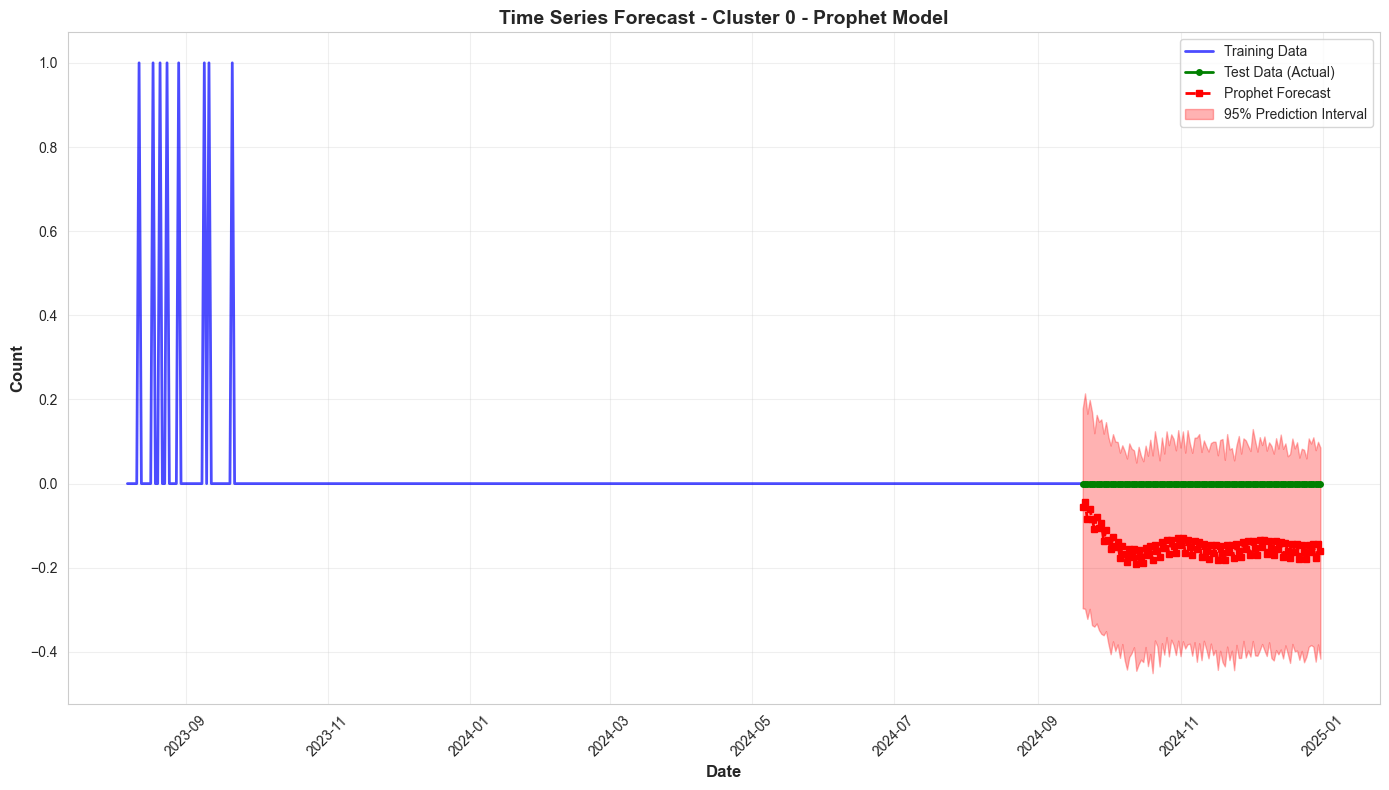

Saved chart: ../data/results/20251221_Prophet_0_forecast_test_chart.png


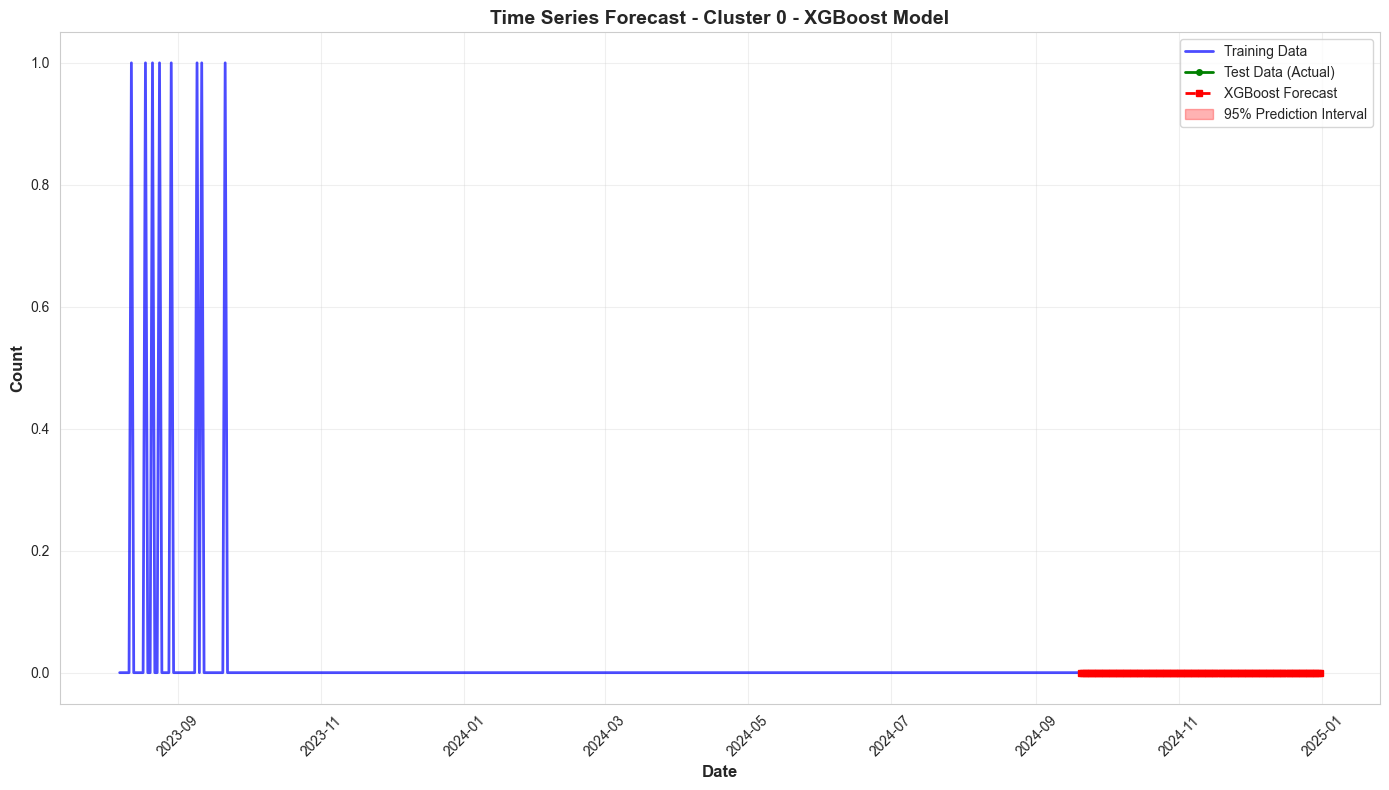

Saved chart: ../data/results/20251221_XGBoost_0_forecast_test_chart.png


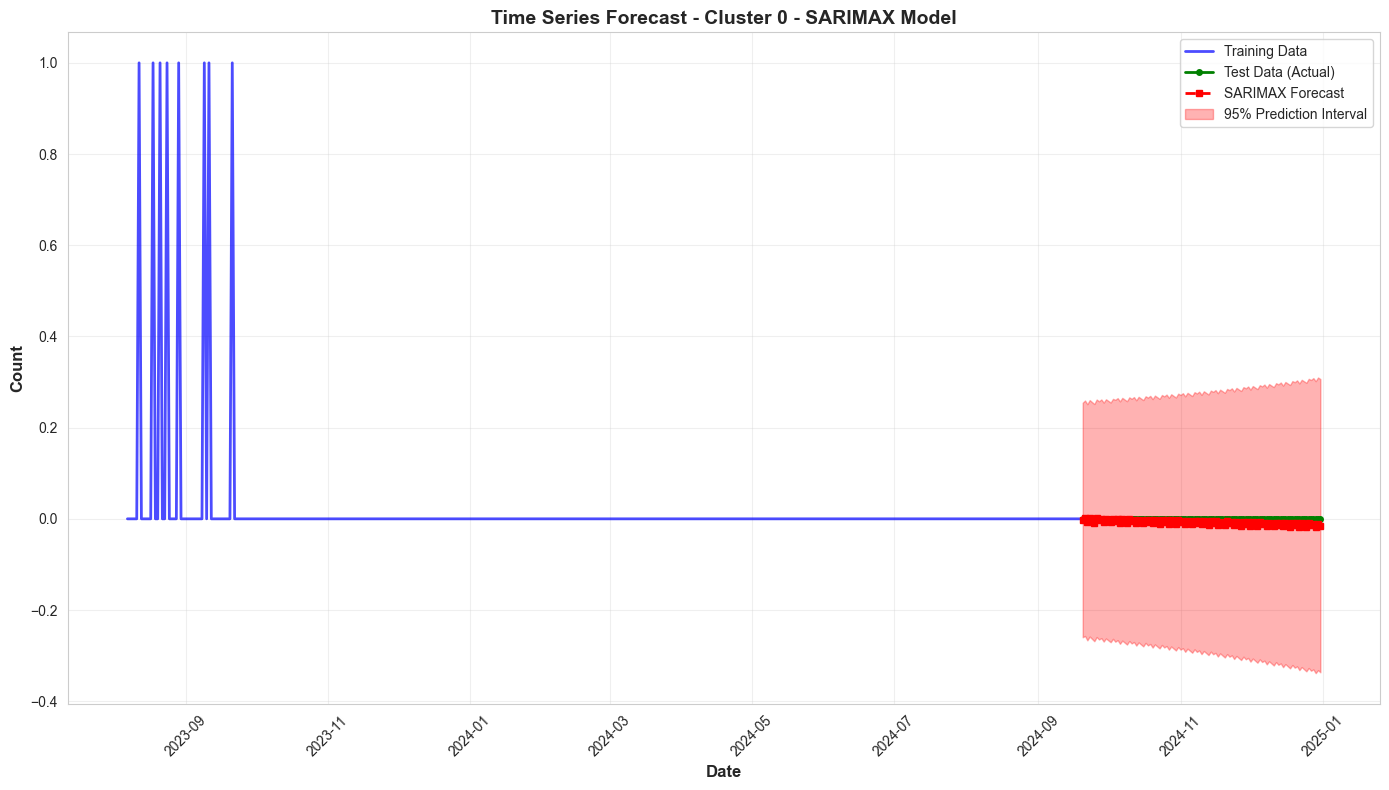

Saved chart: ../data/results/20251221_SARIMAX_0_forecast_test_chart.png


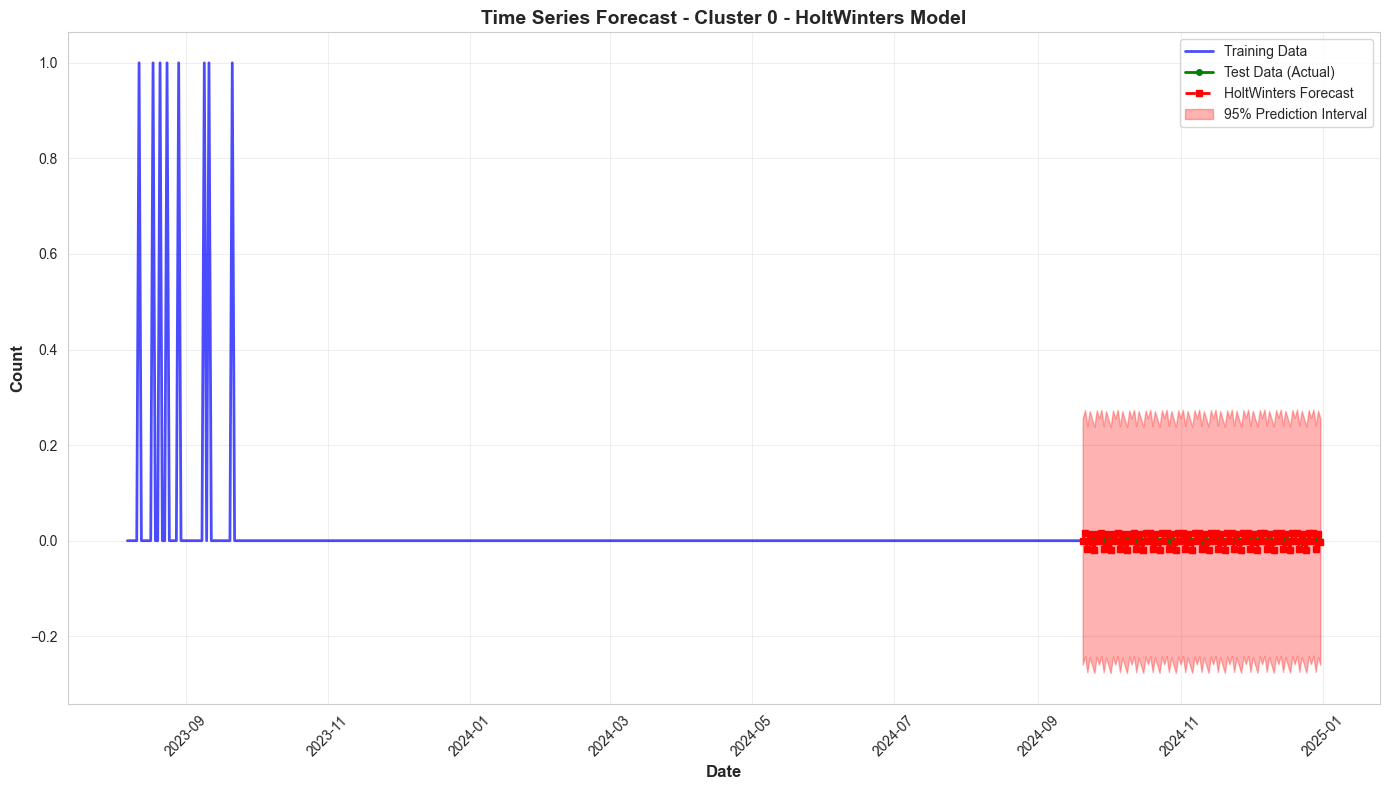

Saved chart: ../data/results/20251221_HoltWinters_0_forecast_test_chart.png


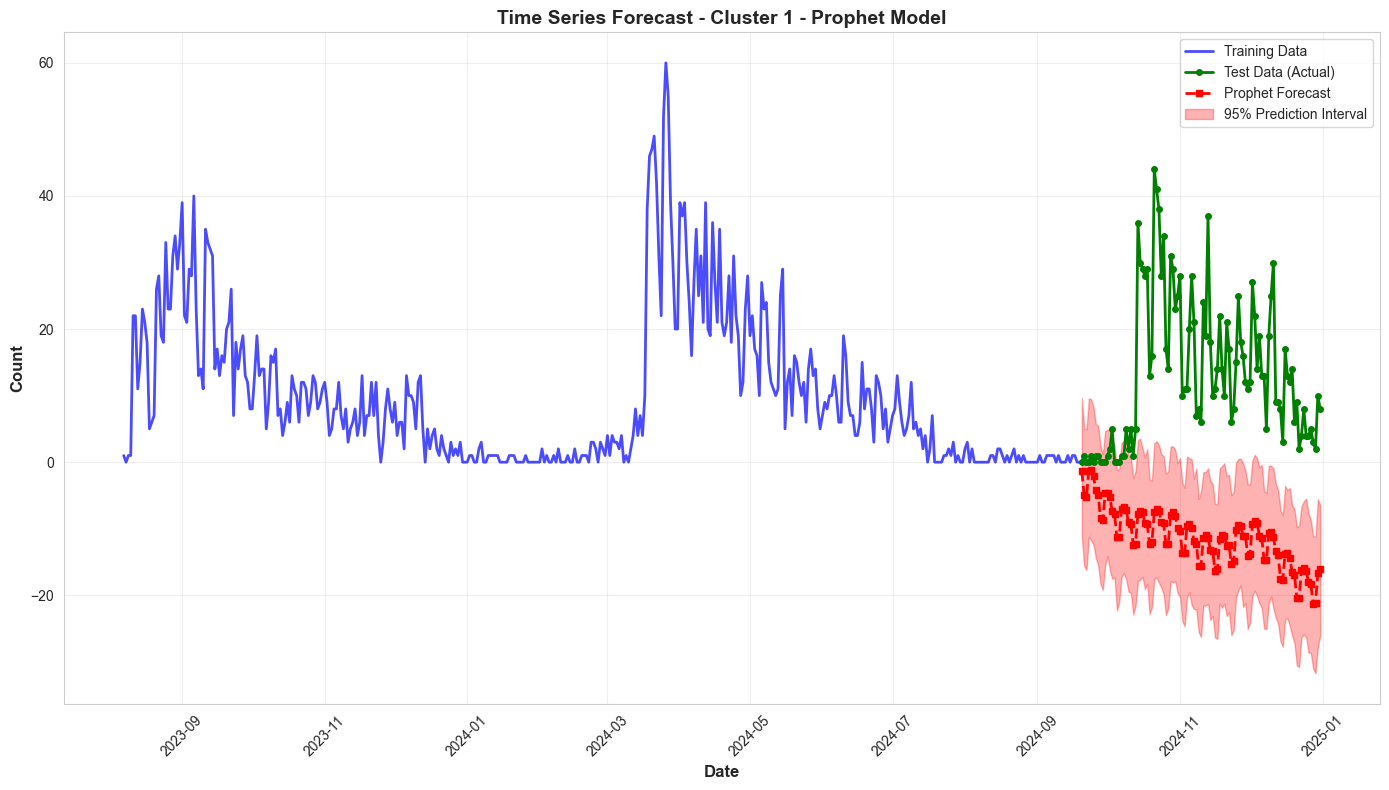

Saved chart: ../data/results/20251221_Prophet_1_forecast_test_chart.png


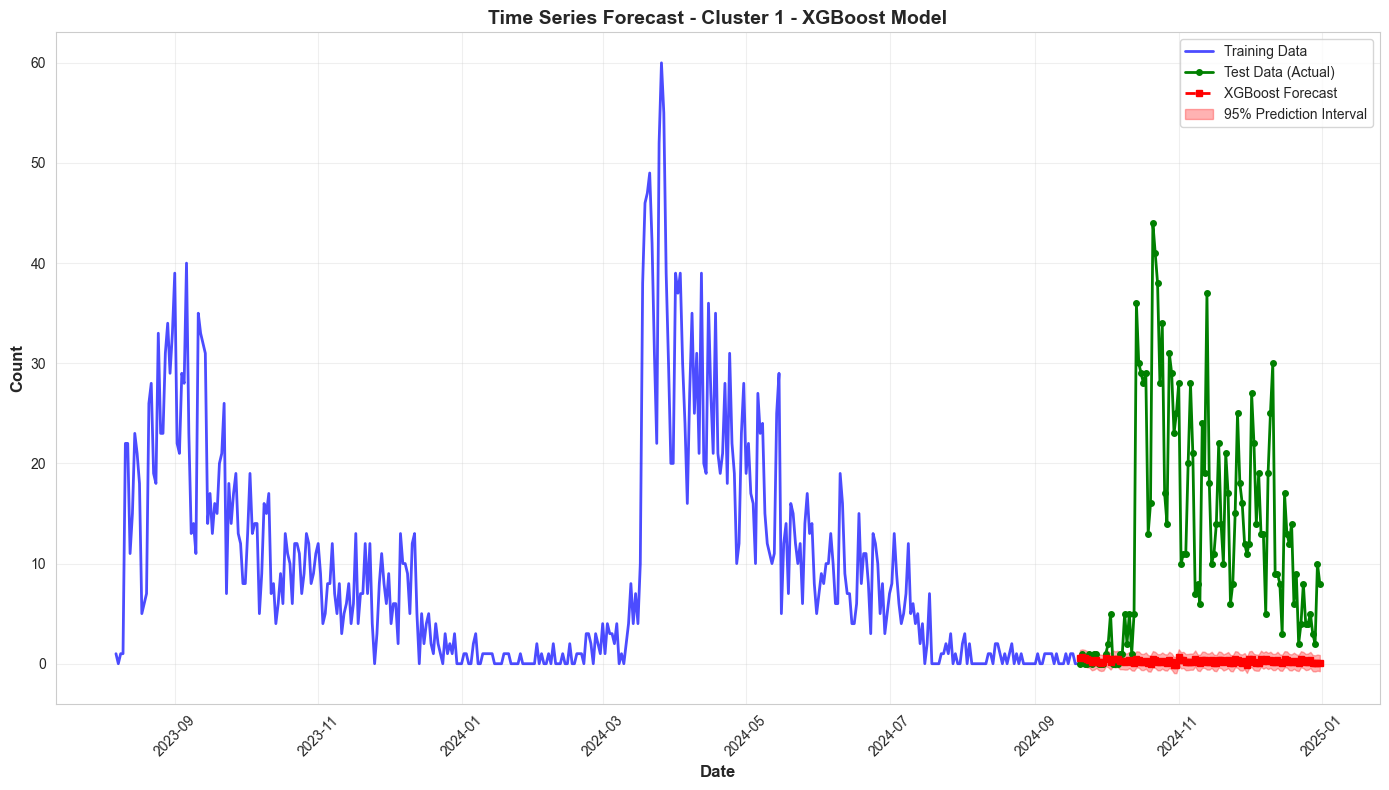

Saved chart: ../data/results/20251221_XGBoost_1_forecast_test_chart.png


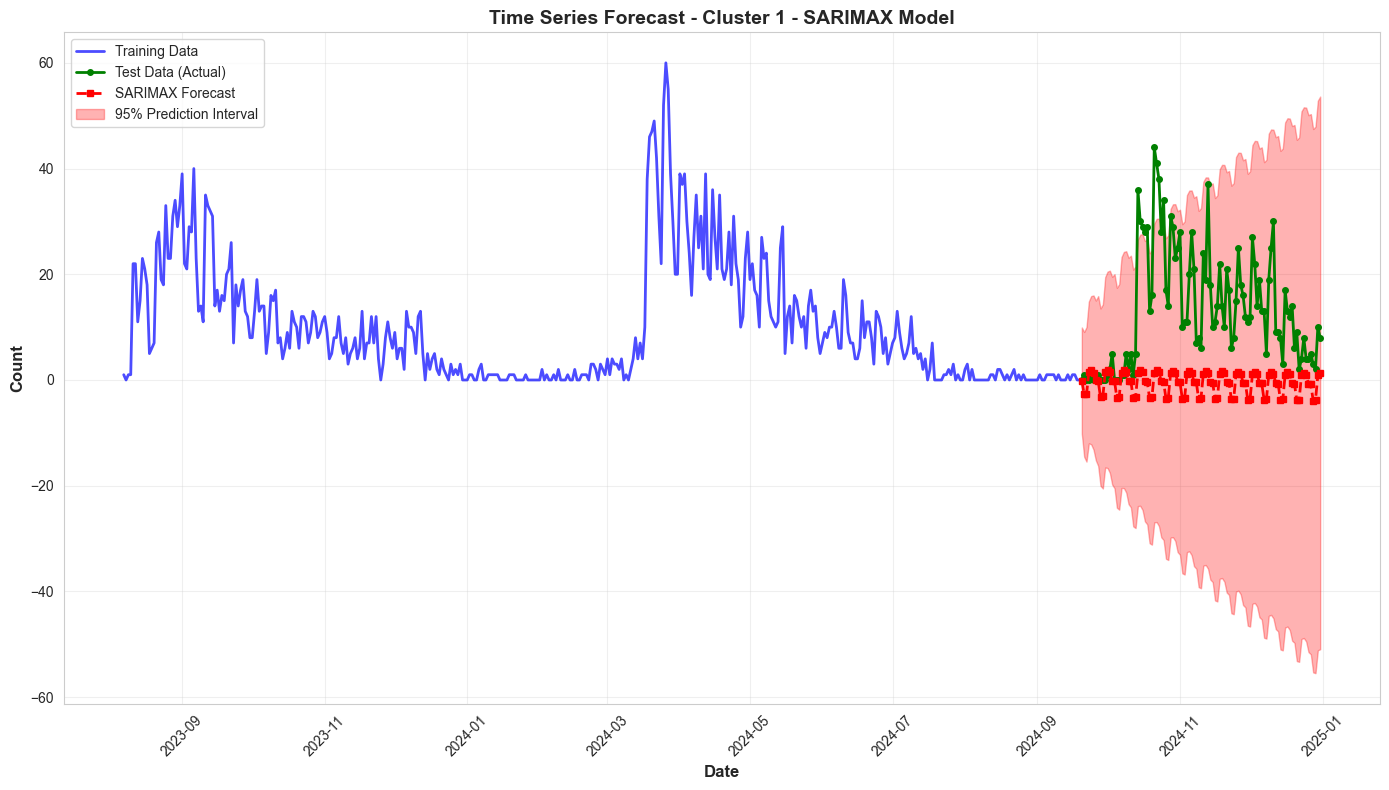

Saved chart: ../data/results/20251221_SARIMAX_1_forecast_test_chart.png


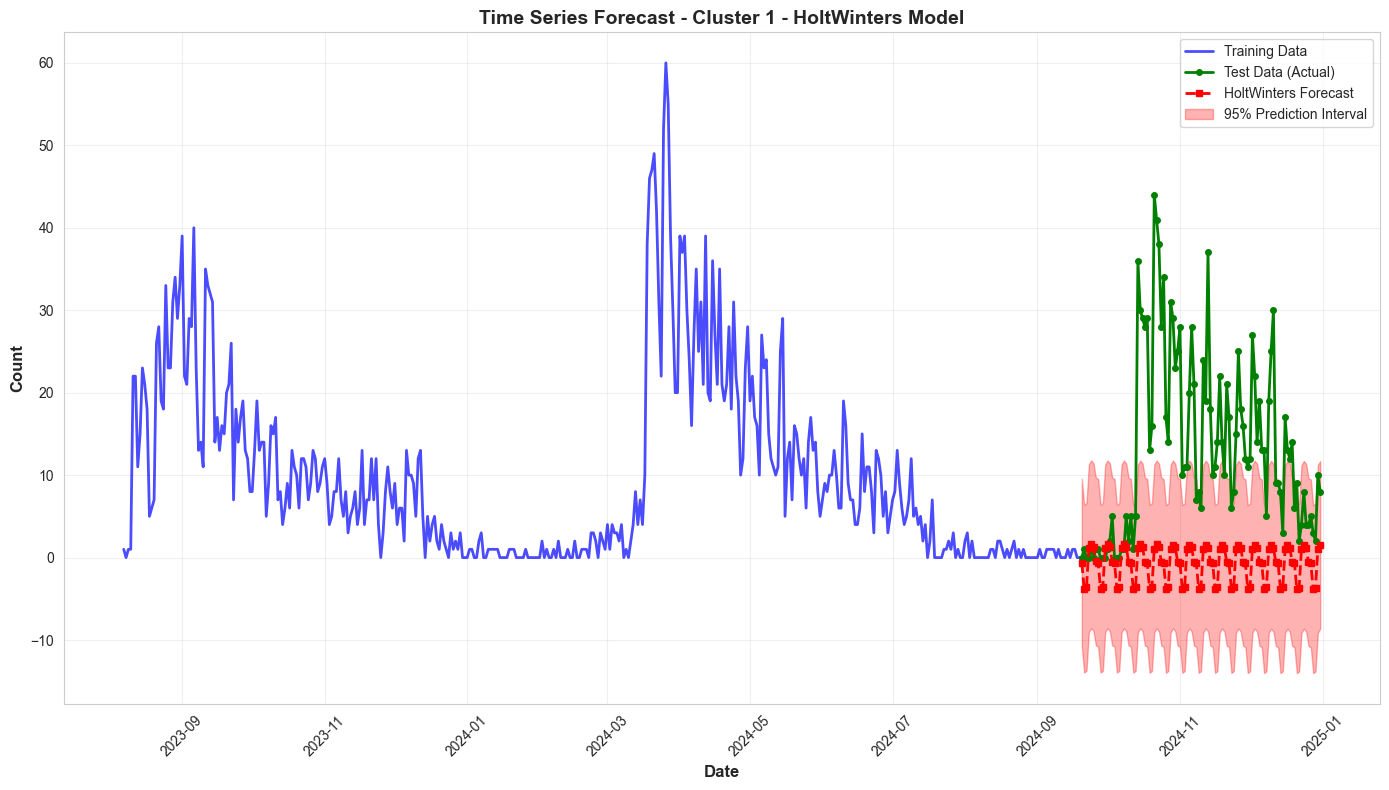

Saved chart: ../data/results/20251221_HoltWinters_1_forecast_test_chart.png


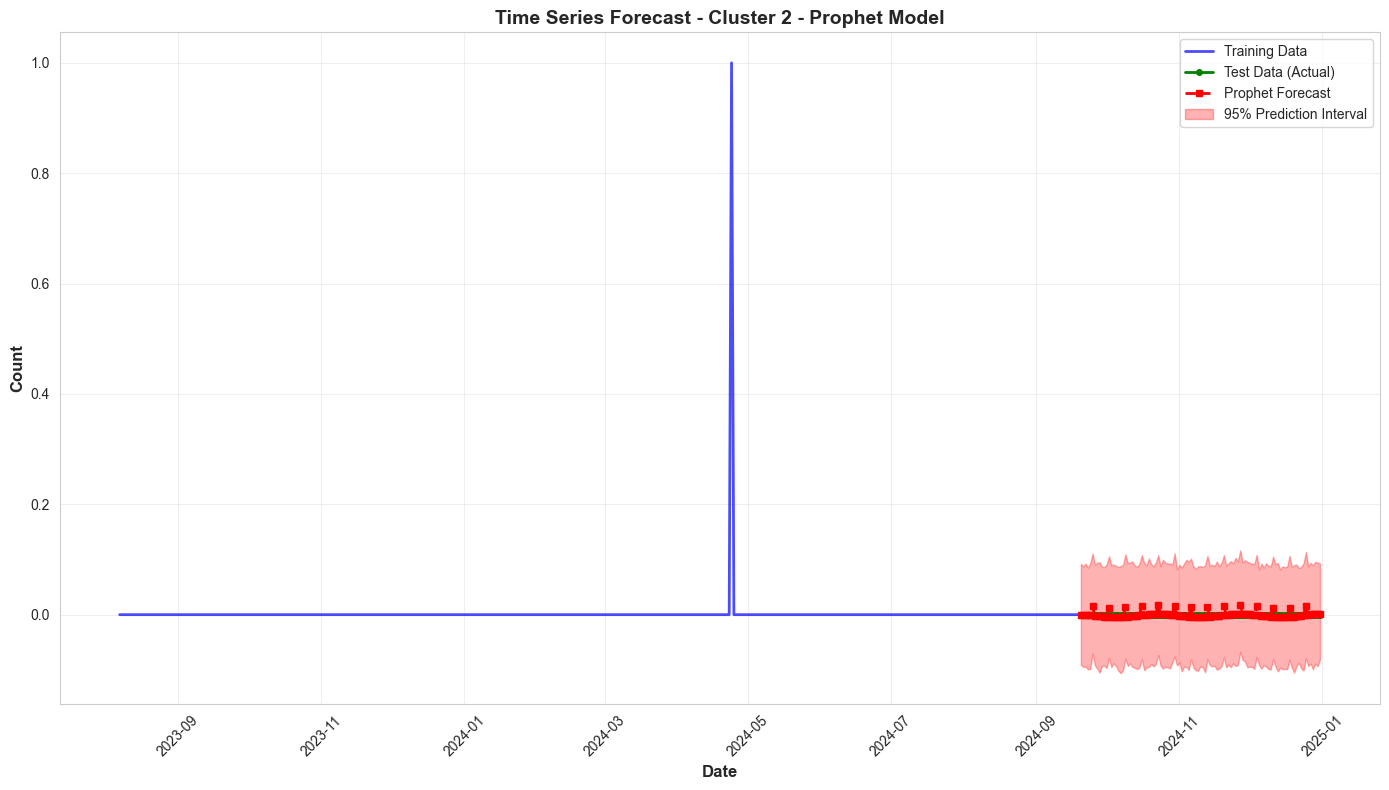

Saved chart: ../data/results/20251221_Prophet_2_forecast_test_chart.png


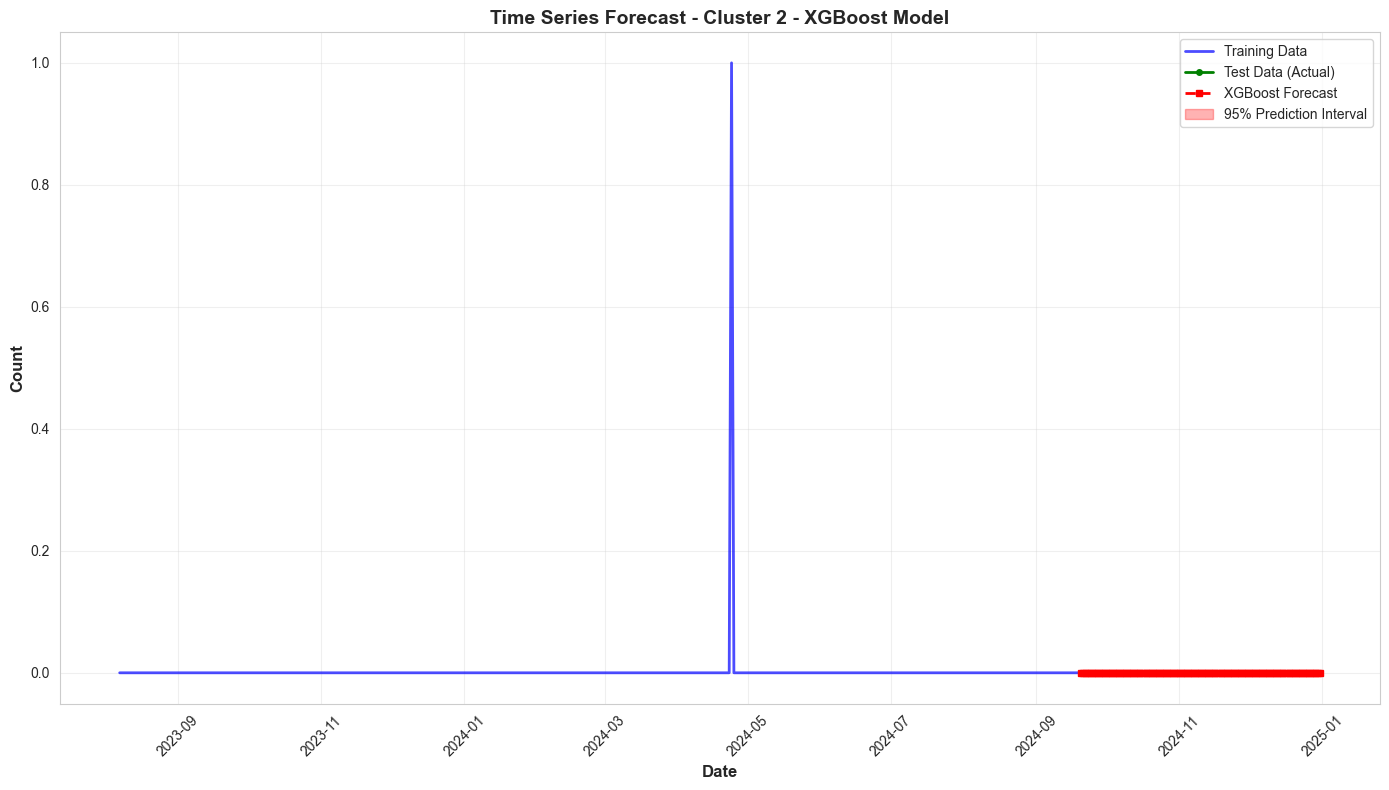

Saved chart: ../data/results/20251221_XGBoost_2_forecast_test_chart.png


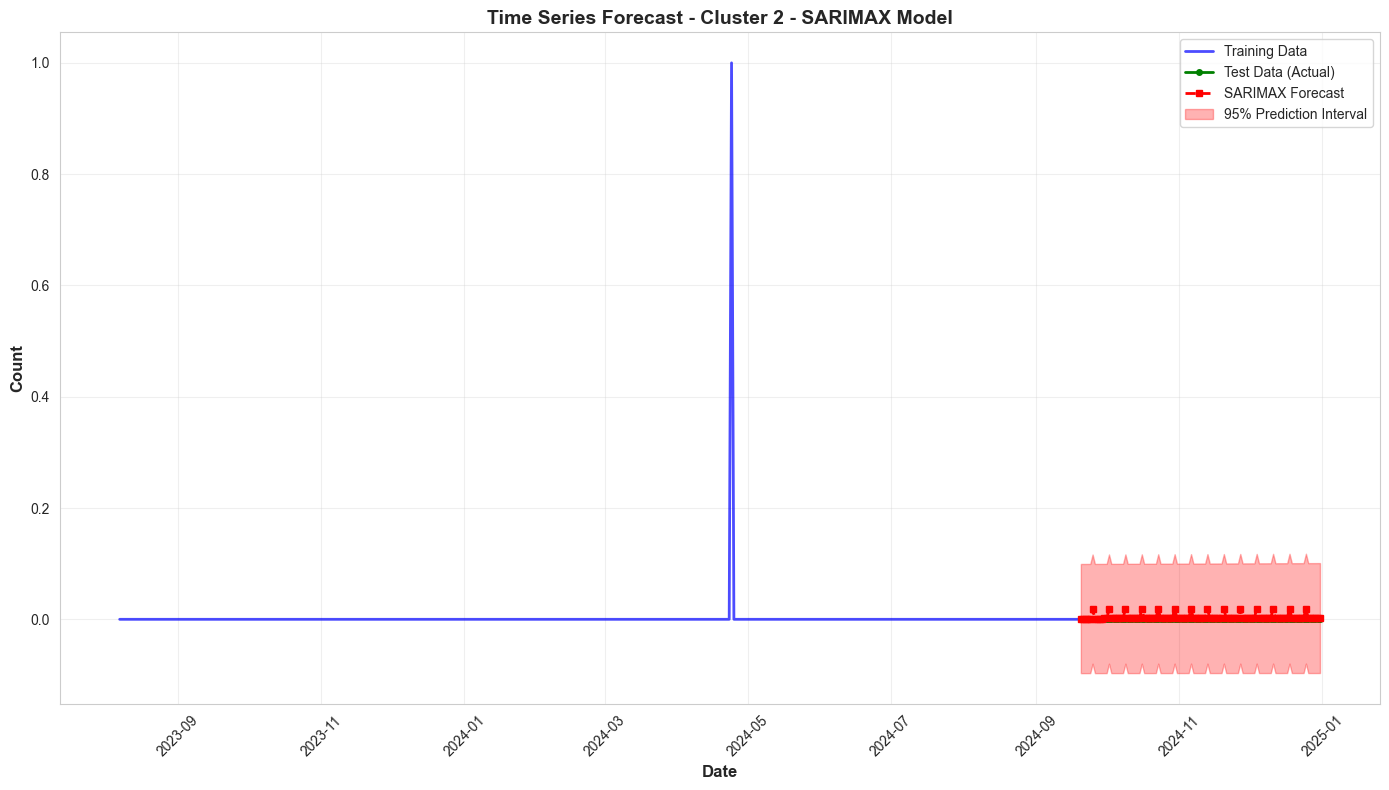

Saved chart: ../data/results/20251221_SARIMAX_2_forecast_test_chart.png


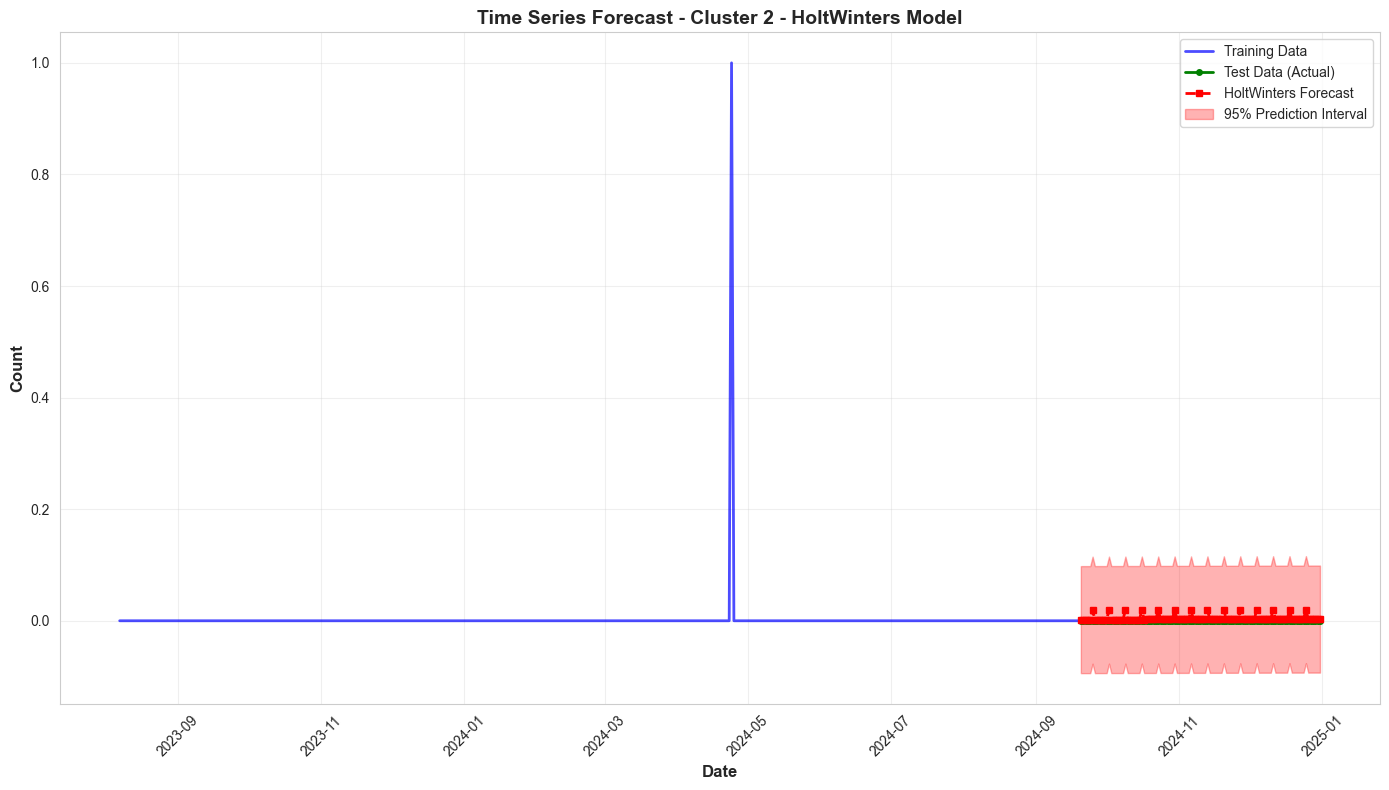

Saved chart: ../data/results/20251221_HoltWinters_2_forecast_test_chart.png

All charts saved and displayed!


In [19]:
print("Creating visualization charts...")

for cluster, cluster_data in all_forecasts.items():
    train_data = cluster_data['train_data']
    train_dates = cluster_data['train_dates']
    test_data = cluster_data['test_data']
    test_dates = cluster_data['test_dates']
    
    for model_name, forecast_data in cluster_data['forecasts'].items():
        fig, ax = plt.subplots(figsize=(14, 8))
        
        ax.plot(train_dates, train_data, label='Training Data', color='blue', linewidth=2, alpha=0.7)
        ax.plot(test_dates, test_data, label='Test Data (Actual)', color='green', linewidth=2, marker='o', markersize=4)
        ax.plot(test_dates, forecast_data['forecast'], 
                label=f'{model_name} Forecast', color='red', linewidth=2, linestyle='--', marker='s', markersize=4)
        ax.fill_between(test_dates, forecast_data['lower'], forecast_data['upper'],
                       alpha=0.3, color='red', label='95% Prediction Interval')
        
        ax.set_xlabel('Date', fontsize=12, fontweight='bold')
        ax.set_ylabel('Count', fontsize=12, fontweight='bold')
        ax.set_title(f'Time Series Forecast - Cluster {cluster} - {model_name} Model', 
                    fontsize=14, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        chart_filename = f'../data/results/{current_date}_{model_name}_{cluster}_forecast_test_chart.png'
        plt.savefig(chart_filename, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        
        print(f"Saved chart: {chart_filename}")

print("\nAll charts saved and displayed!")

## Section 11: Summary - Best Model for Each Cluster

In [20]:
print("="*80)
print("BEST MODEL FOR EACH CLUSTER (Based on RMSE)")
print("="*80)

if len(metrics_df) > 0:
    best_models = metrics_df.loc[metrics_df.groupby('cluster')['rmse'].idxmin()]
    
    print("\nBest Models Summary:")
    print(best_models[['cluster', 'model', 'rmse', 'mae', 'mape', 'mase']].to_string(index=False))
    
    print("\n\nDetailed Metrics for Best Models:")
    for idx, row in best_models.iterrows():
        print(f"\nCluster {int(row['cluster'])} - Best Model: {row['model']}")
        print(f"  RMSE: {row['rmse']:.4f}")
        print(f"  MAE: {row['mae']:.4f}")
        print(f"  MAPE: {row['mape']:.4f}%")
        print(f"  MASE: {row['mase']:.4f}")
        print(f"  Directional Accuracy: {row['directional_accuracy']:.2f}%")
        print(f"  Prediction Interval Coverage: {row['prediction_interval_coverage']:.2f}%")
        print(f"  Jarque-Bera Test Statistic: {row['jarque_bera_test_statistics']:.4f}")
        print(f"  Jarque-Bera Test P-value: {row['jarque_bera_test_pvalue']:.4f}")
        print(f"  ADF Test Statistic: {row['adf_test_statistic']:.4f}")
        print(f"  ADF Test P-value: {row['adf_test_pvalue']:.4f}")
else:
    print("No results available.")

print("\n" + "="*80)
print("Analysis Complete!")
print("="*80)

BEST MODEL FOR EACH CLUSTER (Based on RMSE)

Best Models Summary:
 cluster   model         rmse          mae     mape     mase
       0 XGBoost 5.330038e-06 5.330037e-06      NaN 0.000136
       1 XGBoost 1.701937e+01 1.305358e+01 94.71859 3.561649
       2 XGBoost 6.901243e-08 6.901241e-08      NaN 0.000014


Detailed Metrics for Best Models:

Cluster 0 - Best Model: XGBoost
  RMSE: 0.0000
  MAE: 0.0000
  MAPE: nan%
  MASE: 0.0001
  Directional Accuracy: 100.00%
  Prediction Interval Coverage: 100.00%
  Jarque-Bera Test Statistic: nan
  Jarque-Bera Test P-value: nan
  ADF Test Statistic: nan
  ADF Test P-value: nan

Cluster 1 - Best Model: XGBoost
  RMSE: 17.0194
  MAE: 13.0536
  MAPE: 94.7186%
  MASE: 3.5616
  Directional Accuracy: 65.69%
  Prediction Interval Coverage: 16.50%
  Jarque-Bera Test Statistic: 9.0567
  Jarque-Bera Test P-value: 0.0108
  ADF Test Statistic: -2.3074
  ADF Test P-value: 0.1696

Cluster 2 - Best Model: XGBoost
  RMSE: 0.0000
  MAE: 0.0000
  MAPE: nan%
  MASE